In [2]:
RUNNER_NAME1 = 'Dr Fanatical'
RUNNER_NAME2 = 'Trendy Art'
RACE_LENGTH = 510

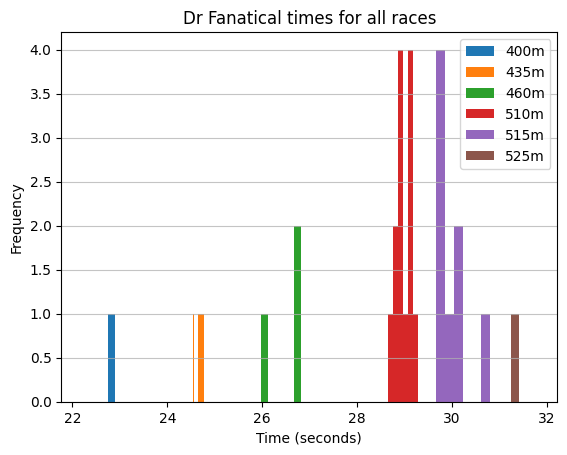

Dr Fanatical times:       
	mean  : 28.96 seconds       
	std   : 0.19 seconds       
	races : 13


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Retrieving data on the Greyhound
formatted_name = RUNNER_NAME1.lower().replace(' ', '-')

url = f'https://www.thegreyhoundrecorder.com.au/greyhounds/{formatted_name}/'

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
tables = pd.read_html(url, storage_options=headers)

races = tables[2]
dist_set = sorted(set(races['Dist']))

# Plotting histograms for each race length in the past
for dist in dist_set:
    plt.hist(races[races['Dist'] == dist]['Time'], bins=6)

plt.title(f'{RUNNER_NAME1} times for all races')
plt.legend([f'{dist}m' for dist in dist_set])
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Creating Normal Distribution for given race
times = races[races['Dist'] == RACE_LENGTH]['Time']
nd_mean1 = times.mean()
nd_var1, nd_std1 = times.var(), times.std()
print(f"{RUNNER_NAME1} times: \
      \n\tmean  : {nd_mean1:.2f} seconds \
      \n\tstd   : {nd_std1:.2f} seconds \
      \n\traces : {len(times)}")

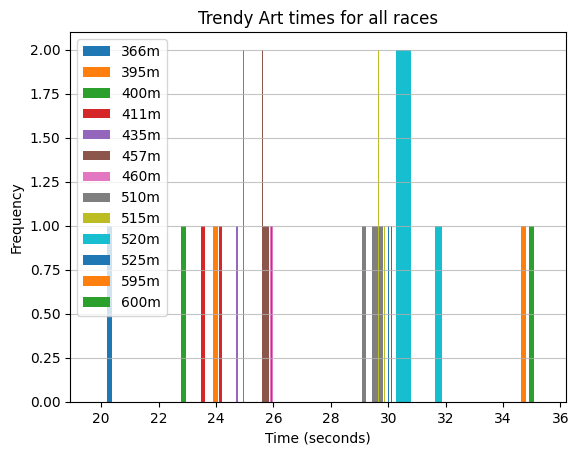

Trendy Art times:       
	mean  : 29.51 seconds       
	std   : 0.31 seconds       
	races : 4


In [4]:
# Retrieving data on the Greyhound
formatted_name = RUNNER_NAME2.lower().replace(' ', '-')

url = f'https://www.thegreyhoundrecorder.com.au/greyhounds/{formatted_name}/'

headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
tables = pd.read_html(url, storage_options=headers)

races = tables[2]
dist_set = sorted(set(races['Dist']))

# Plotting histograms for each race length in the past
for dist in dist_set:
    plt.hist(races[races['Dist'] == dist]['Time'], bins=6)

plt.title(f'{RUNNER_NAME2} times for all races')
plt.legend([f'{dist}m' for dist in dist_set])
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Creating Normal Distribution for given race
times = races[races['Dist'] == RACE_LENGTH]['Time']
nd_mean2 = times.mean()
nd_var2, nd_std2 = times.var(), times.std()
print(f"{RUNNER_NAME2} times: \
      \n\tmean  : {nd_mean2:.2f} seconds \
      \n\tstd   : {nd_std2:.2f} seconds \
      \n\traces : {len(times)}")

In [5]:
# Run Simulations
import random
N_ITER = 1000000
runner1_wins = 0
runner2_wins = 0

nd_std1 = 0.4

for _ in range(N_ITER):
    value1 = random.normalvariate(nd_mean1,nd_std1)
    value2 = random.normalvariate(nd_mean2,nd_std2)
    if value1<value2:
        runner1_wins+=1
    else:
        runner2_wins+=1

#    if value1<value2 and value1<value3:
#        runner1_wins+=1
#    elif value2<value1 and value2<value3:
#        runner2_wins+=1
#    else:
#        runner3_wins+=1

print(f'{RUNNER_NAME1}: {100*runner1_wins/N_ITER}%\nFair Odds: {N_ITER/runner1_wins}')
print(f'{RUNNER_NAME2}: {100*runner2_wins/N_ITER}%\nFair Odds: {N_ITER/runner2_wins}')
#print(f'{RUNNER_NAME3}: {100*runner3_wins/N_ITER}%\nFair Odds: {N_ITER/runner3_wins}')

Dr Fanatical: 85.9374%
Fair Odds: 1.163637717687526
Trendy Art: 14.0626%
Fair Odds: 7.111060543569468
